In [4]:
# What this cell does:
# Load the final test predictions saved from the model evaluation notebook.
# We load the saved files because plant1_test and plant2_test
# are not available in the current notebook kernel.

import pandas as pd
import numpy as np
import os

PREDICTIONS_PATH = "../outputs/predictions/"

plant1_test = pd.read_csv(
    PREDICTIONS_PATH + "plant1_test_predictions.csv"
)

plant2_test = pd.read_csv(
    PREDICTIONS_PATH + "plant2_test_predictions.csv"
)

# Convert DATE_TIME back to datetime
plant1_test["DATE_TIME"] = pd.to_datetime(plant1_test["DATE_TIME"])
plant2_test["DATE_TIME"] = pd.to_datetime(plant2_test["DATE_TIME"])

print("Plant 1 shape:", plant1_test.shape)
print("Plant 2 shape:", plant2_test.shape)

print("\nPlant 1 columns:")
print(plant1_test.columns.tolist())

print("\nPlant 2 columns:")
print(plant2_test.columns.tolist())

Plant 1 shape: (10098, 9)
Plant 2 shape: (10450, 9)

Plant 1 columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AC_POWER', 'TARGET_AC_POWER', 'Persistence', 'Linear_Regression', 'Random_Forest', 'XGBoost']

Plant 2 columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AC_POWER', 'TARGET_AC_POWER', 'Persistence', 'Linear_Regression', 'Random_Forest', 'XGBoost']


In [5]:
# What this cell does:
# Load the final test predictions generated during model evaluation.

PREDICTIONS_PATH = "../outputs/predictions/"

plant1_test_pred = pd.read_csv(
    PREDICTIONS_PATH + "plant1_test_predictions.csv"
)

plant2_test_pred = pd.read_csv(
    PREDICTIONS_PATH + "plant2_test_predictions.csv"
)

print("Plant 1 shape:", plant1_test_pred.shape)
print("Plant 2 shape:", plant2_test_pred.shape)

print("\nPlant 1 columns:")
print(plant1_test_pred.columns.tolist())

print("\nPlant 2 columns:")
print(plant2_test_pred.columns.tolist())

Plant 1 shape: (10098, 9)
Plant 2 shape: (10450, 9)

Plant 1 columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AC_POWER', 'TARGET_AC_POWER', 'Persistence', 'Linear_Regression', 'Random_Forest', 'XGBoost']

Plant 2 columns:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AC_POWER', 'TARGET_AC_POWER', 'Persistence', 'Linear_Regression', 'Random_Forest', 'XGBoost']


In [6]:
# What this cell does:
# Calculate the prediction deviation from the expected AC power.
# A large deviation indicates that actual solar generation is
# significantly different from the expected generation.

def calculate_deviation(df):
    
    df = df.copy()
    
    # Actual generation
    df["ACTUAL_AC_POWER"] = df["TARGET_AC_POWER"]
    
    # Expected generation from the selected baseline
    df["EXPECTED_AC_POWER"] = df["Persistence"]
    
    # Residual = Actual - Expected
    df["RESIDUAL"] = (
        df["ACTUAL_AC_POWER"] - df["EXPECTED_AC_POWER"]
    )
    
    # Absolute percentage deviation
    df["DEVIATION_PCT"] = np.where(
        df["EXPECTED_AC_POWER"] > 0,
        (abs(df["RESIDUAL"]) / df["EXPECTED_AC_POWER"]) * 100,
        0
    )
    
    return df


plant1_deviation = calculate_deviation(plant1_test)
plant2_deviation = calculate_deviation(plant2_test)


print("Plant 1 deviation analysis:")
display(plant1_deviation.head())

print("\nPlant 2 deviation analysis:")
display(plant2_deviation.head())

Plant 1 deviation analysis:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AC_POWER,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT
0,2020-06-13 04:30:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0
1,2020-06-13 04:30:00,4135001,YxYtjZvoooNbGkE,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0
2,2020-06-13 04:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0
3,2020-06-13 04:30:00,4135001,iCRJl6heRkivqQ3,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0
4,2020-06-13 04:30:00,4135001,rGa61gmuvPhdLxV,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0



Plant 2 deviation analysis:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AC_POWER,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT
0,2020-06-13 01:00:00,4136001,oZZkBaNadn6DNKz,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0
1,2020-06-13 01:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0
2,2020-06-13 01:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0
3,2020-06-13 01:00:00,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0
4,2020-06-13 01:00:00,4136001,PeE6FRyGXUgsRhN,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0


In [7]:
# What this cell does:
# Normalize the residual by expected power.
# This makes deviations more comparable across inverters
# with different power capacities.

def add_normalized_residual(df):

    df = df.copy()

    df["NORMALIZED_RESIDUAL"] = np.where(
        df["EXPECTED_AC_POWER"] > 0,
        df["RESIDUAL"] / df["EXPECTED_AC_POWER"],
        0
    )

    return df


plant1_deviation = add_normalized_residual(plant1_deviation)
plant2_deviation = add_normalized_residual(plant2_deviation)

print("Plant 1:")
display(
    plant1_deviation[
        [
            "DATE_TIME",
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "DEVIATION_PCT",
            "NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

print("\nPlant 2:")
display(
    plant2_deviation[
        [
            "DATE_TIME",
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "DEVIATION_PCT",
            "NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

Plant 1:


,DATE_TIME,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT,NORMALIZED_RESIDUAL
0,2020-06-13 04:30:00,3PZuoBAID5Wc2HD,0.0,0.0,0.0,0.0,0.0
1,2020-06-13 04:30:00,YxYtjZvoooNbGkE,0.0,0.0,0.0,0.0,0.0
2,2020-06-13 04:30:00,1BY6WEcLGh8j5v7,0.0,0.0,0.0,0.0,0.0
3,2020-06-13 04:30:00,iCRJl6heRkivqQ3,0.0,0.0,0.0,0.0,0.0
4,2020-06-13 04:30:00,rGa61gmuvPhdLxV,0.0,0.0,0.0,0.0,0.0
5,2020-06-13 04:30:00,zBIq5rxdHJRwDNY,0.0,0.0,0.0,0.0,0.0
6,2020-06-13 04:30:00,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,0.0,0.0
7,2020-06-13 04:30:00,pkci93gMrogZuBj,0.0,0.0,0.0,0.0,0.0
8,2020-06-13 04:30:00,1IF53ai7Xc0U56Y,0.0,0.0,0.0,0.0,0.0
9,2020-06-13 04:30:00,bvBOhCH3iADSZry,0.0,0.0,0.0,0.0,0.0



Plant 2:


,DATE_TIME,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT,NORMALIZED_RESIDUAL
0,2020-06-13 01:00:00,oZZkBaNadn6DNKz,0.0,0.0,0.0,0.0,0.0
1,2020-06-13 01:00:00,4UPUqMRk7TRMgml,0.0,0.0,0.0,0.0,0.0
2,2020-06-13 01:00:00,Et9kgGMDl729KT4,0.0,0.0,0.0,0.0,0.0
3,2020-06-13 01:00:00,Mx2yZCDsyf6DPfv,0.0,0.0,0.0,0.0,0.0
4,2020-06-13 01:00:00,PeE6FRyGXUgsRhN,0.0,0.0,0.0,0.0,0.0
5,2020-06-13 01:00:00,xoJJ8DcxJEcupym,0.0,0.0,0.0,0.0,0.0
6,2020-06-13 01:00:00,IQ2d7wF4YD8zU1Q,0.0,0.0,0.0,0.0,0.0
7,2020-06-13 01:00:00,rrq4fwE8jgrTyWY,0.0,0.0,0.0,0.0,0.0
8,2020-06-13 01:00:00,mqwcsP2rE7J0TFp,0.0,0.0,0.0,0.0,0.0
9,2020-06-13 01:00:00,q49J1IKaHRwDQnt,0.0,0.0,0.0,0.0,0.0


In [8]:
# What this cell does:
# Aggregate the Digital Twin results for each inverter.
# This gives us the average performance deviation of each SOURCE_KEY.

def inverter_summary(df):

    summary = (
        df.groupby("SOURCE_KEY")
        .agg(
            Mean_Actual_Power=("ACTUAL_AC_POWER", "mean"),
            Mean_Expected_Power=("EXPECTED_AC_POWER", "mean"),
            Mean_Residual=("RESIDUAL", "mean"),
            Mean_Deviation_Pct=("DEVIATION_PCT", "mean"),
            Mean_Normalized_Residual=("NORMALIZED_RESIDUAL", "mean"),
            Observation_Count=("SOURCE_KEY", "size")
        )
        .reset_index()
    )

    return summary


plant1_inverter_summary = inverter_summary(plant1_deviation)
plant2_inverter_summary = inverter_summary(plant2_deviation)

print("Plant 1 inverter summary:")
display(plant1_inverter_summary)

print("\nPlant 2 inverter summary:")
display(plant2_inverter_summary)

Plant 1 inverter summary:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count
0,1BY6WEcLGh8j5v7,257.543838,257.543838,6.192094e-17,19.306124,0.037461,459
1,1IF53ai7Xc0U56Y,310.253885,310.253885,0.000000e+00,20.834267,0.060477,459
2,3PZuoBAID5Wc2HD,306.326319,306.326319,5.998591e-17,19.191709,0.038946,459
3,7JYdWkrLSPkdwr4,302.024070,302.024070,0.000000e+00,19.093598,0.041146,459
4,McdE0feGgRqW7Ca,309.071531,309.071531,-3.870058e-18,29.918533,0.151618,459
5,VHMLBKoKgIrUVDU,310.087598,310.087598,1.935029e-18,19.372872,0.042701,459
6,WRmjgnKYAwPKWDb,301.223557,301.223557,-1.935029e-18,19.512651,0.041475,459
7,YxYtjZvoooNbGkE,298.209656,298.209656,6.192094e-17,19.137899,0.040331,459
8,ZnxXDlPa8U1GXgE,304.619930,304.619930,0.000000e+00,29.332394,0.147503,459
9,ZoEaEvLYb1n2sOq,298.751096,298.751096,-5.998591e-17,19.363746,0.043291,459



Plant 2 inverter summary:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count
0,4UPUqMRk7TRMgml,174.049970,174.049970,1.215402e-16,29.899255,0.121593,475
1,81aHJ1q11NBPMrL,255.270641,255.270641,-1.869849e-18,26.550839,0.091406,475
2,9kRcWv60rDACzjR,219.611140,219.611140,-1.869849e-18,27.607268,0.107363,475
3,Et9kgGMDl729KT4,158.704593,158.704593,9.349247e-19,29.844673,0.117200,475
4,IQ2d7wF4YD8zU1Q,225.446501,225.446501,-1.206053e-16,26.544831,0.089172,475
5,LYwnQax7tkwH5Cb,237.682917,237.682917,0.000000e+00,26.983845,0.094049,475
6,LlT2YUhhzqhg5Sw,218.485672,218.485672,1.187354e-16,26.674018,0.094866,475
7,Mx2yZCDsyf6DPfv,161.257652,161.257652,-9.349247e-19,27.916849,0.107786,475
8,NgDl19wMapZy17u,222.451175,222.451175,1.215402e-16,31.306196,0.137258,475
9,PeE6FRyGXUgsRhN,221.627512,221.627512,-1.187354e-16,29.107762,0.112568,475


In [9]:
# What this cell does:
# Compare each inverter against the average performance
# of all inverters in the same plant.

def add_peer_deviation(summary):

    summary = summary.copy()

    plant_mean = summary["Mean_Deviation_Pct"].mean()

    summary["PEER_DEVIATION_PCT"] = (
        summary["Mean_Deviation_Pct"] - plant_mean
    )

    return summary


plant1_inverter_summary = add_peer_deviation(
    plant1_inverter_summary
)

plant2_inverter_summary = add_peer_deviation(
    plant2_inverter_summary
)

print("Plant 1 peer comparison:")
display(plant1_inverter_summary)

print("\nPlant 2 peer comparison:")
display(plant2_inverter_summary)

Plant 1 peer comparison:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count,PEER_DEVIATION_PCT
0,1BY6WEcLGh8j5v7,257.543838,257.543838,6.192094e-17,19.306124,0.037461,459,-2.020990
1,1IF53ai7Xc0U56Y,310.253885,310.253885,0.000000e+00,20.834267,0.060477,459,-0.492846
2,3PZuoBAID5Wc2HD,306.326319,306.326319,5.998591e-17,19.191709,0.038946,459,-2.135405
3,7JYdWkrLSPkdwr4,302.024070,302.024070,0.000000e+00,19.093598,0.041146,459,-2.233515
4,McdE0feGgRqW7Ca,309.071531,309.071531,-3.870058e-18,29.918533,0.151618,459,8.591419
5,VHMLBKoKgIrUVDU,310.087598,310.087598,1.935029e-18,19.372872,0.042701,459,-1.954242
6,WRmjgnKYAwPKWDb,301.223557,301.223557,-1.935029e-18,19.512651,0.041475,459,-1.814463
7,YxYtjZvoooNbGkE,298.209656,298.209656,6.192094e-17,19.137899,0.040331,459,-2.189215
8,ZnxXDlPa8U1GXgE,304.619930,304.619930,0.000000e+00,29.332394,0.147503,459,8.005280
9,ZoEaEvLYb1n2sOq,298.751096,298.751096,-5.998591e-17,19.363746,0.043291,459,-1.963368



Plant 2 peer comparison:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count,PEER_DEVIATION_PCT
0,4UPUqMRk7TRMgml,174.049970,174.049970,1.215402e-16,29.899255,0.121593,475,1.792739
1,81aHJ1q11NBPMrL,255.270641,255.270641,-1.869849e-18,26.550839,0.091406,475,-1.555677
2,9kRcWv60rDACzjR,219.611140,219.611140,-1.869849e-18,27.607268,0.107363,475,-0.499248
3,Et9kgGMDl729KT4,158.704593,158.704593,9.349247e-19,29.844673,0.117200,475,1.738157
4,IQ2d7wF4YD8zU1Q,225.446501,225.446501,-1.206053e-16,26.544831,0.089172,475,-1.561685
5,LYwnQax7tkwH5Cb,237.682917,237.682917,0.000000e+00,26.983845,0.094049,475,-1.122671
6,LlT2YUhhzqhg5Sw,218.485672,218.485672,1.187354e-16,26.674018,0.094866,475,-1.432498
7,Mx2yZCDsyf6DPfv,161.257652,161.257652,-9.349247e-19,27.916849,0.107786,475,-0.189667
8,NgDl19wMapZy17u,222.451175,222.451175,1.215402e-16,31.306196,0.137258,475,3.199680
9,PeE6FRyGXUgsRhN,221.627512,221.627512,-1.187354e-16,29.107762,0.112568,475,1.001247


In [10]:
# What this cell does:
# Rank inverters by the magnitude of their peer deviation.
# This helps identify which inverters deserve further investigation.

plant1_inverter_summary["ABS_PEER_DEVIATION"] = (
    plant1_inverter_summary["PEER_DEVIATION_PCT"].abs()
)

plant2_inverter_summary["ABS_PEER_DEVIATION"] = (
    plant2_inverter_summary["PEER_DEVIATION_PCT"].abs()
)

plant1_inverter_summary = plant1_inverter_summary.sort_values(
    "ABS_PEER_DEVIATION",
    ascending=False
)

plant2_inverter_summary = plant2_inverter_summary.sort_values(
    "ABS_PEER_DEVIATION",
    ascending=False
)

print("Plant 1 - largest peer deviations:")
display(plant1_inverter_summary)

print("\nPlant 2 - largest peer deviations:")
display(plant2_inverter_summary)

Plant 1 - largest peer deviations:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count,PEER_DEVIATION_PCT,ABS_PEER_DEVIATION
4,McdE0feGgRqW7Ca,309.071531,309.071531,-3.870058e-18,29.918533,0.151618,459,8.591419,8.591419
18,wCURE6d3bPkepu2,305.093025,305.093025,1.935029e-18,29.900481,0.150698,459,8.573368,8.573368
8,ZnxXDlPa8U1GXgE,304.619930,304.619930,0.000000e+00,29.332394,0.147503,459,8.005280,8.005280
10,adLQvlD726eNBSB,313.827660,313.827660,3.870058e-18,27.785633,0.129369,459,6.458519,6.458519
13,ih0vzX44oOqAx2f,296.087880,296.087880,-5.998591e-17,26.398529,0.115207,459,5.071415,5.071415
11,bvBOhCH3iADSZry,254.687653,254.687653,1.257769e-16,18.387569,0.031500,459,-2.939545,2.939545
19,z9Y9gH1T5YWrNuG,300.820686,300.820686,1.935029e-18,18.455969,0.036354,459,-2.871144,2.871144
20,zBIq5rxdHJRwDNY,298.813300,298.813300,-1.935029e-18,18.482027,0.034043,459,-2.845086,2.845086
16,sjndEbLyjtCKgGv,302.669637,302.669637,-5.805088e-17,18.519414,0.037073,459,-2.807700,2.807700
12,iCRJl6heRkivqQ3,304.433029,304.433029,0.000000e+00,18.982883,0.041427,459,-2.344230,2.344230



Plant 2 - largest peer deviations:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Mean_Normalized_Residual,Observation_Count,PEER_DEVIATION_PCT,ABS_PEER_DEVIATION
10,Qf4GUc1pJu5T6c6,147.272302,147.272302,-1.206053e-16,33.503264,0.157299,475,5.396749,5.396749
8,NgDl19wMapZy17u,222.451175,222.451175,1.215402e-16,31.306196,0.137258,475,3.199680,3.199680
11,Quc1TzYxW2pYoWX,152.383565,152.383565,-5.983518e-17,25.774071,0.070877,475,-2.332445,2.332445
20,xMbIugepa2P7lBB,223.790057,223.790057,1.477181e-16,25.910062,0.084696,475,-2.196454,2.196454
0,4UPUqMRk7TRMgml,174.049970,174.049970,1.215402e-16,29.899255,0.121593,475,1.792739,1.792739
3,Et9kgGMDl729KT4,158.704593,158.704593,9.349247e-19,29.844673,0.117200,475,1.738157,1.738157
19,vOuJvMaM2sgwLmb,252.720942,252.720942,5.796533e-17,26.413096,0.092676,475,-1.693420,1.693420
21,xoJJ8DcxJEcupym,255.006700,255.006700,-1.196704e-16,26.496986,0.091328,475,-1.609530,1.609530
15,oZ35aAeoifZaQzV,165.577802,165.577802,-1.486530e-16,29.696672,0.123221,475,1.590156,1.590156
4,IQ2d7wF4YD8zU1Q,225.446501,225.446501,-1.206053e-16,26.544831,0.089172,475,-1.561685,1.561685


In [11]:
# What this cell does:
# Calculate the absolute size of the residual.
# We use magnitude because both large positive and large negative
# deviations can indicate unusual behavior.

plant1_deviation["ABS_RESIDUAL"] = (
    plant1_deviation["RESIDUAL"].abs()
)

plant2_deviation["ABS_RESIDUAL"] = (
    plant2_deviation["RESIDUAL"].abs()
)


# Absolute normalized residual
plant1_deviation["ABS_NORMALIZED_RESIDUAL"] = (
    plant1_deviation["NORMALIZED_RESIDUAL"].abs()
)

plant2_deviation["ABS_NORMALIZED_RESIDUAL"] = (
    plant2_deviation["NORMALIZED_RESIDUAL"].abs()
)

print("Plant 1:")
display(
    plant1_deviation[
        [
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

print("\nPlant 2:")
display(
    plant2_deviation[
        [
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

Plant 1:


,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL
0,3PZuoBAID5Wc2HD,0.0,0.0,0.0,0.0,0.0
1,YxYtjZvoooNbGkE,0.0,0.0,0.0,0.0,0.0
2,1BY6WEcLGh8j5v7,0.0,0.0,0.0,0.0,0.0
3,iCRJl6heRkivqQ3,0.0,0.0,0.0,0.0,0.0
4,rGa61gmuvPhdLxV,0.0,0.0,0.0,0.0,0.0
5,zBIq5rxdHJRwDNY,0.0,0.0,0.0,0.0,0.0
6,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,0.0,0.0
7,pkci93gMrogZuBj,0.0,0.0,0.0,0.0,0.0
8,1IF53ai7Xc0U56Y,0.0,0.0,0.0,0.0,0.0
9,bvBOhCH3iADSZry,0.0,0.0,0.0,0.0,0.0



Plant 2:


,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL
0,oZZkBaNadn6DNKz,0.0,0.0,0.0,0.0,0.0
1,4UPUqMRk7TRMgml,0.0,0.0,0.0,0.0,0.0
2,Et9kgGMDl729KT4,0.0,0.0,0.0,0.0,0.0
3,Mx2yZCDsyf6DPfv,0.0,0.0,0.0,0.0,0.0
4,PeE6FRyGXUgsRhN,0.0,0.0,0.0,0.0,0.0
5,xoJJ8DcxJEcupym,0.0,0.0,0.0,0.0,0.0
6,IQ2d7wF4YD8zU1Q,0.0,0.0,0.0,0.0,0.0
7,rrq4fwE8jgrTyWY,0.0,0.0,0.0,0.0,0.0
8,mqwcsP2rE7J0TFp,0.0,0.0,0.0,0.0,0.0
9,q49J1IKaHRwDQnt,0.0,0.0,0.0,0.0,0.0


In [12]:
# What this cell does:
# Summarize the distribution of residual deviations
# for every inverter.

def residual_distribution(df):

    summary = (
        df.groupby("SOURCE_KEY")
        .agg(
            Median_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                "median"
            ),

            P90_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                lambda x: x.quantile(0.90)
            ),

            P95_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                lambda x: x.quantile(0.95)
            ),

            Max_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                "max"
            ),

            Observation_Count=(
                "SOURCE_KEY",
                "size"
            )
        )
        .reset_index()
    )

    return summary


plant1_residual_summary = residual_distribution(
    plant1_deviation
)

plant2_residual_summary = residual_distribution(
    plant2_deviation
)

print("Plant 1 residual distribution:")
display(plant1_residual_summary)

print("\nPlant 2 residual distribution:")
display(plant2_residual_summary)

Plant 1 residual distribution:


,SOURCE_KEY,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Max_Abs_Norm_Residual,Observation_Count
0,1BY6WEcLGh8j5v7,0.022476,0.502872,0.759464,5.026373,459
1,1IF53ai7Xc0U56Y,0.035349,0.493361,0.737011,11.609524,459
2,3PZuoBAID5Wc2HD,0.032871,0.487774,0.729449,5.079142,459
3,7JYdWkrLSPkdwr4,0.035185,0.494186,0.738767,7.347148,459
4,McdE0feGgRqW7Ca,0.032434,0.495545,0.753009,38.569892,459
5,VHMLBKoKgIrUVDU,0.035455,0.489991,0.737538,7.506627,459
6,WRmjgnKYAwPKWDb,0.034270,0.486485,0.745765,5.156154,459
7,YxYtjZvoooNbGkE,0.032166,0.483433,0.719556,7.050663,459
8,ZnxXDlPa8U1GXgE,0.030313,0.485858,0.754845,37.382979,459
9,ZoEaEvLYb1n2sOq,0.028271,0.487107,0.721182,6.962825,459



Plant 2 residual distribution:


,SOURCE_KEY,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Max_Abs_Norm_Residual,Observation_Count
0,4UPUqMRk7TRMgml,0.000000,0.686004,1.000000,16.957932,475
1,81aHJ1q11NBPMrL,0.029173,0.642413,0.894370,15.793872,475
2,9kRcWv60rDACzjR,0.006323,0.639130,0.927594,16.257225,475
3,Et9kgGMDl729KT4,0.000000,0.721647,1.000000,23.271503,475
4,IQ2d7wF4YD8zU1Q,0.013222,0.640910,1.000000,12.394052,475
5,LYwnQax7tkwH5Cb,0.025561,0.652041,0.934465,15.441250,475
6,LlT2YUhhzqhg5Sw,0.005283,0.656857,0.920374,17.184080,475
7,Mx2yZCDsyf6DPfv,0.000000,0.677509,1.000000,15.448845,475
8,NgDl19wMapZy17u,0.016352,0.654210,1.000000,19.455150,475
9,PeE6FRyGXUgsRhN,0.016373,0.660670,1.000000,21.500000,475


In [13]:
# What this cell does:
# Remove observations where expected power is zero or extremely small.
#
# Why?
# During night/low-irradiance periods, expected power is close to zero.
# Dividing by a value close to zero can create misleadingly large
# normalized residuals.
#
# We therefore calculate anomaly statistics only when the plant
# is actually producing meaningful power.

MIN_EXPECTED_POWER = 50


plant1_active = plant1_deviation[
    plant1_deviation["EXPECTED_AC_POWER"] >= MIN_EXPECTED_POWER
].copy()

plant2_active = plant2_deviation[
    plant2_deviation["EXPECTED_AC_POWER"] >= MIN_EXPECTED_POWER
].copy()


print("Plant 1 active observations:", plant1_active.shape)
print("Plant 2 active observations:", plant2_active.shape)

Plant 1 active observations: (5076, 16)
Plant 2 active observations: (4711, 16)


In [14]:
# What this cell does:
# Recalculate normalized residual only during meaningful
# power-generation periods.

plant1_active["NORMALIZED_RESIDUAL"] = (
    plant1_active["RESIDUAL"] /
    plant1_active["EXPECTED_AC_POWER"]
)

plant2_active["NORMALIZED_RESIDUAL"] = (
    plant2_active["RESIDUAL"] /
    plant2_active["EXPECTED_AC_POWER"]
)


plant1_active["ABS_NORMALIZED_RESIDUAL"] = (
    plant1_active["NORMALIZED_RESIDUAL"].abs()
)

plant2_active["ABS_NORMALIZED_RESIDUAL"] = (
    plant2_active["NORMALIZED_RESIDUAL"].abs()
)


print("Plant 1:")
display(
    plant1_active[
        [
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

print("\nPlant 2:")
display(
    plant2_active[
        [
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL"
        ]
    ].head(10)
)

Plant 1:


,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL
176,adLQvlD726eNBSB,123.471429,63.962500,59.508929,0.930372,0.930372
177,McdE0feGgRqW7Ca,102.362500,56.657143,45.705357,0.806701,0.806701
178,zBIq5rxdHJRwDNY,98.257143,56.787500,41.469643,0.730260,0.730260
179,3PZuoBAID5Wc2HD,121.262500,61.957143,59.305357,0.957200,0.957200
180,zVJPv84UY57bAof,100.128571,56.137500,43.991071,0.783631,0.783631
181,7JYdWkrLSPkdwr4,109.625000,58.328571,51.296429,0.879439,0.879439
182,z9Y9gH1T5YWrNuG,100.750000,55.585714,45.164286,0.812516,0.812516
183,iCRJl6heRkivqQ3,100.585714,57.375000,43.210714,0.753128,0.753128
184,WRmjgnKYAwPKWDb,116.462500,60.671429,55.791071,0.919561,0.919561
185,VHMLBKoKgIrUVDU,110.912500,59.085714,51.826786,0.877146,0.877146



Plant 2:


,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL
484,LlT2YUhhzqhg5Sw,109.960000,67.633333,42.326667,0.625826,0.625826
485,Mx2yZCDsyf6DPfv,109.493333,73.178571,36.314762,0.496249,0.496249
486,mqwcsP2rE7J0TFp,108.806667,65.928571,42.878095,0.650372,0.650372
487,WcxssY2VbP4hApt,112.364286,71.573333,40.790952,0.569918,0.569918
488,q49J1IKaHRwDQnt,111.960000,68.626667,43.333333,0.631436,0.631436
489,Qf4GUc1pJu5T6c6,107.746667,68.685714,39.060952,0.568691,0.568691
490,V94E5Ben1TlhnDV,111.535714,74.173333,37.362381,0.503717,0.503717
491,vOuJvMaM2sgwLmb,111.042857,72.246667,38.796190,0.536996,0.536996
492,9kRcWv60rDACzjR,109.421429,69.840000,39.581429,0.566744,0.566744
493,oZ35aAeoifZaQzV,109.973333,72.800000,37.173333,0.510623,0.510623


In [15]:
# What this cell does:
# Calculate inverter-level abnormal-performance statistics
# using only meaningful generation periods.

def active_inverter_summary(df):

    summary = (
        df.groupby("SOURCE_KEY")
        .agg(
            Mean_Actual_Power=("ACTUAL_AC_POWER", "mean"),
            Mean_Expected_Power=("EXPECTED_AC_POWER", "mean"),
            Mean_Residual=("RESIDUAL", "mean"),

            Mean_Deviation_Pct=("DEVIATION_PCT", "mean"),

            Median_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                "median"
            ),

            P90_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                lambda x: x.quantile(0.90)
            ),

            P95_Abs_Norm_Residual=(
                "ABS_NORMALIZED_RESIDUAL",
                lambda x: x.quantile(0.95)
            ),

            Observation_Count=("SOURCE_KEY", "size")
        )
        .reset_index()
    )

    return summary


plant1_active_summary = active_inverter_summary(
    plant1_active
)

plant2_active_summary = active_inverter_summary(
    plant2_active
)


print("Plant 1:")
display(plant1_active_summary)

print("\nPlant 2:")
display(plant2_active_summary)

Plant 1:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Observation_Count
0,1BY6WEcLGh8j5v7,535.415054,537.864051,-2.448997,27.053295,0.209570,0.550925,0.688127,219
1,1IF53ai7Xc0U56Y,610.819563,611.995979,-1.176416,24.205062,0.175441,0.515882,0.617271,232
2,3PZuoBAID5Wc2HD,603.090217,604.272968,-1.182751,25.482574,0.197348,0.518211,0.650403,232
3,7JYdWkrLSPkdwr4,594.636276,595.772291,-1.136014,24.686352,0.182839,0.516815,0.615338,232
4,McdE0feGgRqW7Ca,608.573547,609.712355,-1.138808,24.156646,0.189968,0.531620,0.667340,232
5,VHMLBKoKgIrUVDU,610.549363,611.705705,-1.156342,25.055354,0.193187,0.516949,0.619375,232
6,WRmjgnKYAwPKWDb,593.046599,594.216643,-1.170043,25.717070,0.203654,0.520825,0.656091,232
7,YxYtjZvoooNbGkE,587.134660,588.253633,-1.118973,25.018457,0.200091,0.517940,0.632769,232
8,ZnxXDlPa8U1GXgE,599.754070,600.885505,-1.131435,24.714242,0.204218,0.507038,0.644184,232
9,ZoEaEvLYb1n2sOq,588.227260,589.344794,-1.117534,24.822477,0.195063,0.517341,0.635273,232



Plant 2:


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Observation_Count
0,4UPUqMRk7TRMgml,404.168593,421.392369,-17.223775,36.477378,0.283374,0.835804,1.000000,195
1,81aHJ1q11NBPMrL,510.081158,516.095604,-6.014446,32.341781,0.248733,0.683393,0.837504,234
2,9kRcWv60rDACzjR,468.332364,474.350546,-6.018182,34.848323,0.260933,0.707341,0.894662,219
3,Et9kgGMDl729KT4,373.163306,387.605440,-14.442134,35.940635,0.290699,0.769089,0.994327,193
4,IQ2d7wF4YD8zU1Q,475.819472,482.602370,-6.782898,35.924713,0.260721,0.750394,1.000000,221
5,LYwnQax7tkwH5Cb,473.302413,478.709619,-5.407206,33.317459,0.273048,0.700990,0.882450,235
6,LlT2YUhhzqhg5Sw,466.355951,471.753305,-5.397354,33.587091,0.267941,0.716650,0.892213,219
7,Mx2yZCDsyf6DPfv,389.541132,404.890600,-15.349468,38.036803,0.276130,0.855865,1.000000,188
8,NgDl19wMapZy17u,466.065559,476.029481,-9.963922,35.309277,0.263441,0.716069,1.000000,221
9,PeE6FRyGXUgsRhN,467.388690,476.103126,-8.714435,36.016093,0.248730,0.721228,1.000000,220


In [16]:
# What this cell does:
# Compare each inverter's average deviation with the
# average deviation of all active inverters in the plant.

def calculate_peer_deviation(summary):

    summary = summary.copy()

    plant_mean = summary["Mean_Deviation_Pct"].mean()

    summary["PEER_DEVIATION_PCT"] = (
        summary["Mean_Deviation_Pct"] -
        plant_mean
    )

    return summary


plant1_active_summary = calculate_peer_deviation(
    plant1_active_summary
)

plant2_active_summary = calculate_peer_deviation(
    plant2_active_summary
)


display(plant1_active_summary)

display(plant2_active_summary)

,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Observation_Count,PEER_DEVIATION_PCT
0,1BY6WEcLGh8j5v7,535.415054,537.864051,-2.448997,27.053295,0.209570,0.550925,0.688127,219,2.299059
1,1IF53ai7Xc0U56Y,610.819563,611.995979,-1.176416,24.205062,0.175441,0.515882,0.617271,232,-0.549174
2,3PZuoBAID5Wc2HD,603.090217,604.272968,-1.182751,25.482574,0.197348,0.518211,0.650403,232,0.728338
3,7JYdWkrLSPkdwr4,594.636276,595.772291,-1.136014,24.686352,0.182839,0.516815,0.615338,232,-0.067884
4,McdE0feGgRqW7Ca,608.573547,609.712355,-1.138808,24.156646,0.189968,0.531620,0.667340,232,-0.597590
5,VHMLBKoKgIrUVDU,610.549363,611.705705,-1.156342,25.055354,0.193187,0.516949,0.619375,232,0.301118
6,WRmjgnKYAwPKWDb,593.046599,594.216643,-1.170043,25.717070,0.203654,0.520825,0.656091,232,0.962835
7,YxYtjZvoooNbGkE,587.134660,588.253633,-1.118973,25.018457,0.200091,0.517940,0.632769,232,0.264221
8,ZnxXDlPa8U1GXgE,599.754070,600.885505,-1.131435,24.714242,0.204218,0.507038,0.644184,232,-0.039994
9,ZoEaEvLYb1n2sOq,588.227260,589.344794,-1.117534,24.822477,0.195063,0.517341,0.635273,232,0.068241


,SOURCE_KEY,Mean_Actual_Power,Mean_Expected_Power,Mean_Residual,Mean_Deviation_Pct,Median_Abs_Norm_Residual,P90_Abs_Norm_Residual,P95_Abs_Norm_Residual,Observation_Count,PEER_DEVIATION_PCT
0,4UPUqMRk7TRMgml,404.168593,421.392369,-17.223775,36.477378,0.283374,0.835804,1.000000,195,0.634150
1,81aHJ1q11NBPMrL,510.081158,516.095604,-6.014446,32.341781,0.248733,0.683393,0.837504,234,-3.501447
2,9kRcWv60rDACzjR,468.332364,474.350546,-6.018182,34.848323,0.260933,0.707341,0.894662,219,-0.994905
3,Et9kgGMDl729KT4,373.163306,387.605440,-14.442134,35.940635,0.290699,0.769089,0.994327,193,0.097407
4,IQ2d7wF4YD8zU1Q,475.819472,482.602370,-6.782898,35.924713,0.260721,0.750394,1.000000,221,0.081485
5,LYwnQax7tkwH5Cb,473.302413,478.709619,-5.407206,33.317459,0.273048,0.700990,0.882450,235,-2.525768
6,LlT2YUhhzqhg5Sw,466.355951,471.753305,-5.397354,33.587091,0.267941,0.716650,0.892213,219,-2.256137
7,Mx2yZCDsyf6DPfv,389.541132,404.890600,-15.349468,38.036803,0.276130,0.855865,1.000000,188,2.193575
8,NgDl19wMapZy17u,466.065559,476.029481,-9.963922,35.309277,0.263441,0.716069,1.000000,221,-0.533951
9,PeE6FRyGXUgsRhN,467.388690,476.103126,-8.714435,36.016093,0.248730,0.721228,1.000000,220,0.172865


In [17]:
# What this cell does:
# Flag individual observations as anomalies when their
# absolute normalized residual exceeds the inverter's P95 threshold.

def flag_anomalies(deviation_df, summary_df):

    df = deviation_df.copy()

    # Create source-wise P95 threshold mapping
    threshold_map = summary_df[
        ["SOURCE_KEY", "P95_Abs_Norm_Residual"]
    ].copy()

    # Add threshold to every observation
    df = df.merge(
        threshold_map,
        on="SOURCE_KEY",
        how="left"
    )

    # Flag anomaly
    df["ANOMALY_FLAG"] = (
        df["ABS_NORMALIZED_RESIDUAL"]
        > df["P95_Abs_Norm_Residual"]
    )

    # Human-readable status
    df["STATUS"] = df["ANOMALY_FLAG"].map({
        True: "ANOMALY",
        False: "NORMAL"
    })

    return df


# Apply to both plants
plant1_anomalies = flag_anomalies(
    plant1_deviation,
    plant1_active_summary
)

plant2_anomalies = flag_anomalies(
    plant2_deviation,
    plant2_active_summary
)


print("Plant 1 anomaly data:")
display(plant1_anomalies.head(10))

print("\nPlant 2 anomaly data:")
display(plant2_anomalies.head(10))

Plant 1 anomaly data:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AC_POWER,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT,NORMALIZED_RESIDUAL,ABS_RESIDUAL,ABS_NORMALIZED_RESIDUAL,P95_Abs_Norm_Residual,ANOMALY_FLAG,STATUS
0,2020-06-13 04:30:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.650403,False,NORMAL
1,2020-06-13 04:30:00,4135001,YxYtjZvoooNbGkE,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.632769,False,NORMAL
2,2020-06-13 04:30:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.688127,False,NORMAL
3,2020-06-13 04:30:00,4135001,iCRJl6heRkivqQ3,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.637952,False,NORMAL
4,2020-06-13 04:30:00,4135001,rGa61gmuvPhdLxV,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.626814,False,NORMAL
5,2020-06-13 04:30:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.651013,False,NORMAL
6,2020-06-13 04:30:00,4135001,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.644184,False,NORMAL
7,2020-06-13 04:30:00,4135001,pkci93gMrogZuBj,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.642635,False,NORMAL
8,2020-06-13 04:30:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.617271,False,NORMAL
9,2020-06-13 04:30:00,4135001,bvBOhCH3iADSZry,0.0,0.0,0.0,74.142694,0.0,0.366492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.688854,False,NORMAL



Plant 2 anomaly data:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AC_POWER,TARGET_AC_POWER,Persistence,Linear_Regression,Random_Forest,XGBoost,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,DEVIATION_PCT,NORMALIZED_RESIDUAL,ABS_RESIDUAL,ABS_NORMALIZED_RESIDUAL,P95_Abs_Norm_Residual,ANOMALY_FLAG,STATUS
0,2020-06-13 01:00:00,4136001,oZZkBaNadn6DNKz,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
1,2020-06-13 01:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
2,2020-06-13 01:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.994327,False,NORMAL
3,2020-06-13 01:00:00,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
4,2020-06-13 01:00:00,4136001,PeE6FRyGXUgsRhN,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
5,2020-06-13 01:00:00,4136001,xoJJ8DcxJEcupym,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.822589,False,NORMAL
6,2020-06-13 01:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
7,2020-06-13 01:00:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960362,False,NORMAL
8,2020-06-13 01:00:00,4136001,mqwcsP2rE7J0TFp,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,False,NORMAL
9,2020-06-13 01:00:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,0.0,-31.45553,0.0,-0.224189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.890100,False,NORMAL


In [18]:
# What this cell does:
# Summarize the number and percentage of anomalous observations.

def anomaly_summary(df):

    total = len(df)
    anomalies = df["ANOMALY_FLAG"].sum()

    return pd.DataFrame({
        "Total_Observations": [total],
        "Anomalies": [anomalies],
        "Normal": [total - anomalies],
        "Anomaly_Percentage": [
            (anomalies / total) * 100
        ]
    })


plant1_anomaly_summary = anomaly_summary(plant1_anomalies)
plant2_anomaly_summary = anomaly_summary(plant2_anomalies)

print("Plant 1:")
display(plant1_anomaly_summary)

print("Plant 2:")
display(plant2_anomaly_summary)

Plant 1:


,Total_Observations,Anomalies,Normal,Anomaly_Percentage
0,10098,657,9441,6.506239


Plant 2:


,Total_Observations,Anomalies,Normal,Anomaly_Percentage
0,10450,479,9971,4.583732


In [19]:
# What this cell does:
# Count anomalies for each inverter/source and calculate
# the anomaly percentage for each inverter.

def inverter_anomaly_summary(df):

    summary = (
        df.groupby("SOURCE_KEY")
        .agg(
            Total_Observations=("ANOMALY_FLAG", "size"),
            Anomalies=("ANOMALY_FLAG", "sum")
        )
        .reset_index()
    )

    summary["Normal"] = (
        summary["Total_Observations"] - summary["Anomalies"]
    )

    summary["Anomaly_Percentage"] = (
        summary["Anomalies"]
        / summary["Total_Observations"]
        * 100
    )

    # Most anomalous inverters first
    summary = summary.sort_values(
        "Anomaly_Percentage",
        ascending=False
    ).reset_index(drop=True)

    return summary


plant1_inverter_anomalies = inverter_anomaly_summary(
    plant1_anomalies
)

plant2_inverter_anomalies = inverter_anomaly_summary(
    plant2_anomalies
)


print("Plant 1 - Inverter Anomaly Summary")
display(plant1_inverter_anomalies)

print("Plant 2 - Inverter Anomaly Summary")
display(plant2_inverter_anomalies)

Plant 1 - Inverter Anomaly Summary


,SOURCE_KEY,Total_Observations,Anomalies,Normal,Anomaly_Percentage
0,adLQvlD726eNBSB,459,32,427,6.971678
1,1IF53ai7Xc0U56Y,459,31,428,6.753813
2,wCURE6d3bPkepu2,459,31,428,6.753813
3,ih0vzX44oOqAx2f,459,31,428,6.753813
4,ZnxXDlPa8U1GXgE,459,31,428,6.753813
5,McdE0feGgRqW7Ca,459,31,428,6.753813
6,zVJPv84UY57bAof,459,30,429,6.535948
7,zBIq5rxdHJRwDNY,459,30,429,6.535948
8,uHbuxQJl8lW7ozc,459,30,429,6.535948
9,3PZuoBAID5Wc2HD,459,30,429,6.535948


Plant 2 - Inverter Anomaly Summary


,SOURCE_KEY,Total_Observations,Anomalies,Normal,Anomaly_Percentage
0,xoJJ8DcxJEcupym,475,29,446,6.105263
1,vOuJvMaM2sgwLmb,475,29,446,6.105263
2,Et9kgGMDl729KT4,475,28,447,5.894737
3,LlT2YUhhzqhg5Sw,475,27,448,5.684211
4,LYwnQax7tkwH5Cb,475,27,448,5.684211
5,81aHJ1q11NBPMrL,475,27,448,5.684211
6,q49J1IKaHRwDQnt,475,27,448,5.684211
7,WcxssY2VbP4hApt,475,27,448,5.684211
8,9kRcWv60rDACzjR,475,26,449,5.473684
9,xMbIugepa2P7lBB,475,26,449,5.473684


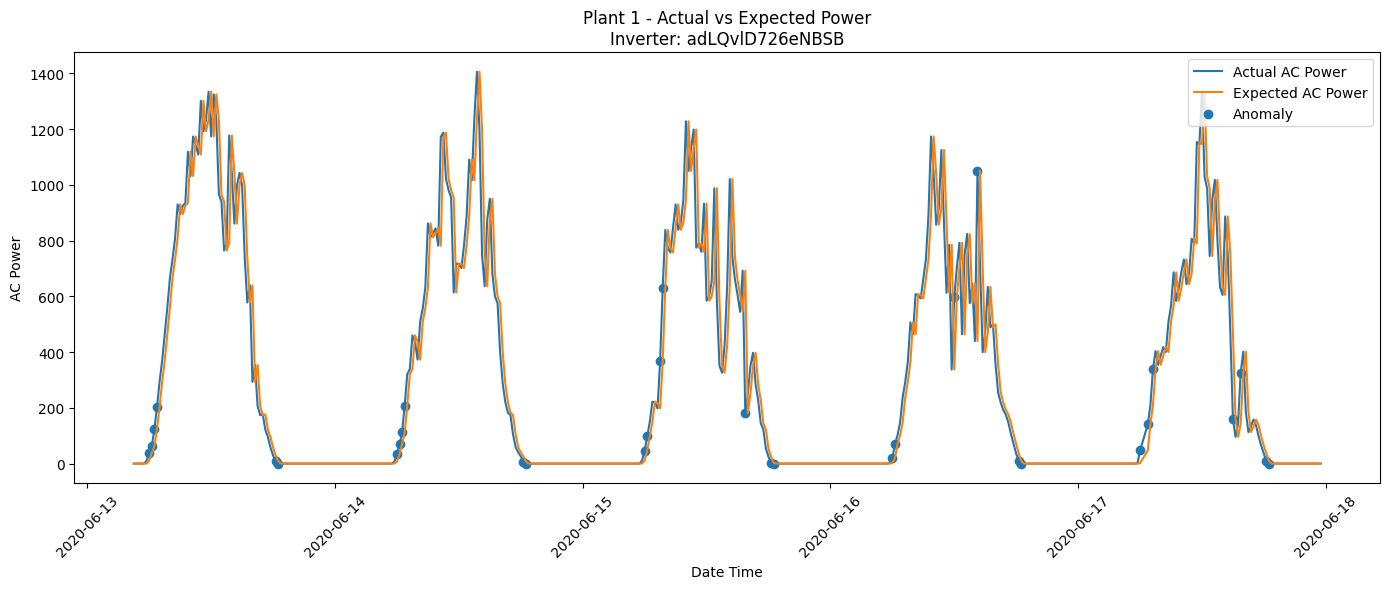

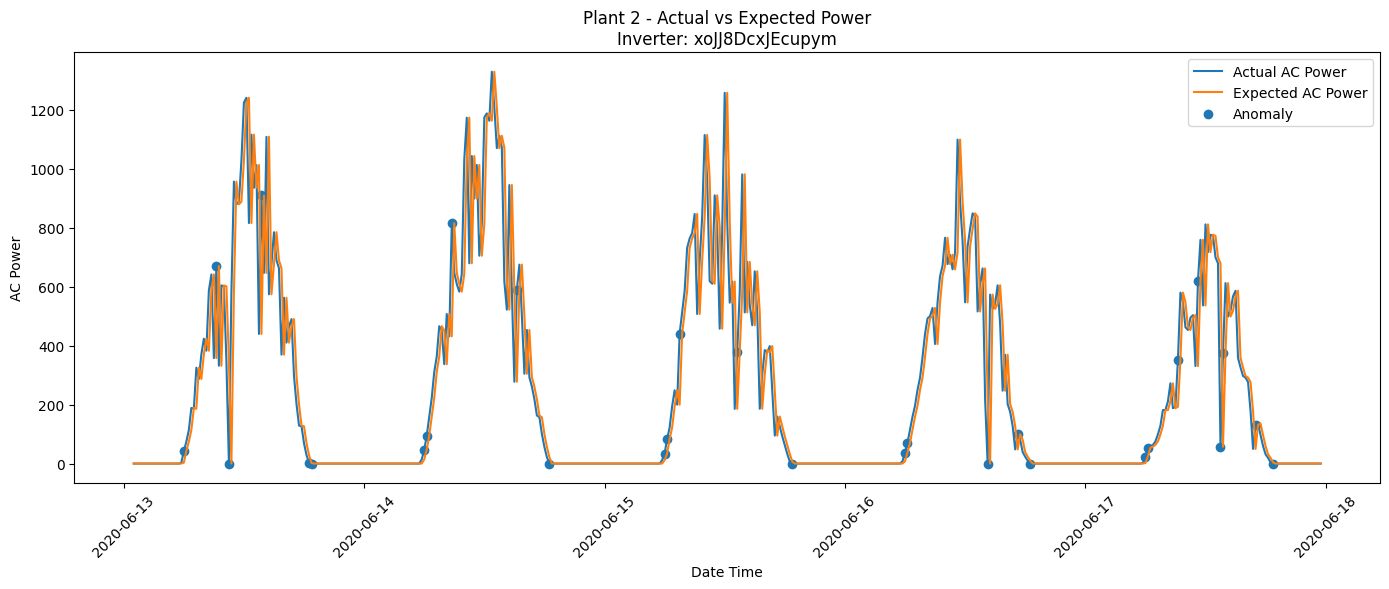

In [20]:
# What this cell does:
# Visualize actual vs expected AC power for the inverter
# with the highest anomaly percentage in each plant.

import matplotlib.pyplot as plt


# -----------------------------
# Plant 1
# -----------------------------

top_plant1_source = (
    plant1_inverter_anomalies
    .iloc[0]["SOURCE_KEY"]
)

plant1_source_data = (
    plant1_anomalies[
        plant1_anomalies["SOURCE_KEY"] == top_plant1_source
    ]
    .sort_values("DATE_TIME")
)


plt.figure(figsize=(14, 6))

plt.plot(
    plant1_source_data["DATE_TIME"],
    plant1_source_data["ACTUAL_AC_POWER"],
    label="Actual AC Power"
)

plt.plot(
    plant1_source_data["DATE_TIME"],
    plant1_source_data["EXPECTED_AC_POWER"],
    label="Expected AC Power"
)

anomalies = plant1_source_data[
    plant1_source_data["ANOMALY_FLAG"]
]

plt.scatter(
    anomalies["DATE_TIME"],
    anomalies["ACTUAL_AC_POWER"],
    label="Anomaly"
)

plt.title(
    f"Plant 1 - Actual vs Expected Power\n"
    f"Inverter: {top_plant1_source}"
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------------
# Plant 2
# -----------------------------

top_plant2_source = (
    plant2_inverter_anomalies
    .iloc[0]["SOURCE_KEY"]
)

plant2_source_data = (
    plant2_anomalies[
        plant2_anomalies["SOURCE_KEY"] == top_plant2_source
    ]
    .sort_values("DATE_TIME")
)


plt.figure(figsize=(14, 6))

plt.plot(
    plant2_source_data["DATE_TIME"],
    plant2_source_data["ACTUAL_AC_POWER"],
    label="Actual AC Power"
)

plt.plot(
    plant2_source_data["DATE_TIME"],
    plant2_source_data["EXPECTED_AC_POWER"],
    label="Expected AC Power"
)

anomalies = plant2_source_data[
    plant2_source_data["ANOMALY_FLAG"]
]

plt.scatter(
    anomalies["DATE_TIME"],
    anomalies["ACTUAL_AC_POWER"],
    label="Anomaly"
)

plt.title(
    f"Plant 2 - Actual vs Expected Power\n"
    f"Inverter: {top_plant2_source}"
)

plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# What this cell does:
# Create a clean final anomaly report containing only
# observations that were flagged as anomalies.

plant1_anomaly_report = (
    plant1_anomalies[
        plant1_anomalies["ANOMALY_FLAG"] == True
    ]
    [
        [
            "DATE_TIME",
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL",
            "P95_Abs_Norm_Residual"
        ]
    ]
    .sort_values(
        "ABS_NORMALIZED_RESIDUAL",
        ascending=False
    )
    .reset_index(drop=True)
)


plant2_anomaly_report = (
    plant2_anomalies[
        plant2_anomalies["ANOMALY_FLAG"] == True
    ]
    [
        [
            "DATE_TIME",
            "SOURCE_KEY",
            "ACTUAL_AC_POWER",
            "EXPECTED_AC_POWER",
            "RESIDUAL",
            "NORMALIZED_RESIDUAL",
            "ABS_NORMALIZED_RESIDUAL",
            "P95_Abs_Norm_Residual"
        ]
    ]
    .sort_values(
        "ABS_NORMALIZED_RESIDUAL",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Plant 1 - Final Anomaly Report")
display(plant1_anomaly_report.head(20))

print("Plant 2 - Final Anomaly Report")
display(plant2_anomaly_report.head(20))

Plant 1 - Final Anomaly Report


,DATE_TIME,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL,P95_Abs_Norm_Residual
0,2020-06-17 06:00:00,wCURE6d3bPkepu2,45.100000,1.137500,43.962500,38.648352,38.648352,0.668720
1,2020-06-17 06:00:00,McdE0feGgRqW7Ca,46.000000,1.162500,44.837500,38.569892,38.569892,0.667340
2,2020-06-17 06:00:00,ZnxXDlPa8U1GXgE,45.100000,1.175000,43.925000,37.382979,37.382979,0.644184
3,2020-06-17 06:00:00,adLQvlD726eNBSB,46.900000,1.385714,45.514286,32.845361,32.845361,0.617079
4,2020-06-17 06:00:00,ih0vzX44oOqAx2f,25.900000,1.137500,24.762500,21.769231,21.769231,0.649437
5,2020-06-16 06:00:00,wCURE6d3bPkepu2,19.228571,1.262500,17.966071,14.230552,14.230552,0.668720
6,2020-06-16 06:00:00,ZnxXDlPa8U1GXgE,19.100000,1.262500,17.837500,14.128713,14.128713,0.644184
7,2020-06-16 06:00:00,McdE0feGgRqW7Ca,19.471429,1.300000,18.171429,13.978022,13.978022,0.667340
8,2020-06-16 06:00:00,ih0vzX44oOqAx2f,18.985714,1.275000,17.710714,13.890756,13.890756,0.649437
9,2020-06-16 06:00:00,adLQvlD726eNBSB,19.914286,1.557143,18.357143,11.788991,11.788991,0.617079


Plant 2 - Final Anomaly Report


,DATE_TIME,SOURCE_KEY,ACTUAL_AC_POWER,EXPECTED_AC_POWER,RESIDUAL,NORMALIZED_RESIDUAL,ABS_NORMALIZED_RESIDUAL,P95_Abs_Norm_Residual
0,2020-06-17 06:00:00,Qf4GUc1pJu5T6c6,23.633333,0.642857,22.990476,35.762963,35.762963,1.000000
1,2020-06-13 06:00:00,Et9kgGMDl729KT4,33.460000,1.378571,32.081429,23.271503,23.271503,0.994327
2,2020-06-17 06:00:00,PeE6FRyGXUgsRhN,24.300000,1.080000,23.220000,21.500000,21.500000,1.000000
3,2020-06-17 06:00:00,oZ35aAeoifZaQzV,24.933333,1.207143,23.726190,19.654832,19.654832,1.000000
4,2020-06-13 06:00:00,NgDl19wMapZy17u,41.046667,2.006667,39.040000,19.455150,19.455150,1.000000
5,2020-06-17 06:00:00,Et9kgGMDl729KT4,22.313333,1.120000,21.193333,18.922619,18.922619,0.994327
6,2020-06-13 06:00:00,Qf4GUc1pJu5T6c6,40.946667,2.146667,38.800000,18.074534,18.074534,1.000000
7,2020-06-17 06:00:00,rrq4fwE8jgrTyWY,23.020000,1.260000,21.760000,17.269841,17.269841,0.960362
8,2020-06-17 06:00:00,NgDl19wMapZy17u,24.213333,1.326667,22.886667,17.251256,17.251256,1.000000
9,2020-06-17 06:00:00,LlT2YUhhzqhg5Sw,24.366667,1.340000,23.026667,17.184080,17.184080,0.892213


In [22]:
# What this cell does:
# Save the final anomaly reports for later use
# in the dashboard and project documentation.

ANOMALY_PATH = "../outputs/anomalies/"
os.makedirs(ANOMALY_PATH, exist_ok=True)

plant1_anomaly_report.to_csv(
    ANOMALY_PATH + "plant1_anomaly_report.csv",
    index=False
)

plant2_anomaly_report.to_csv(
    ANOMALY_PATH + "plant2_anomaly_report.csv",
    index=False
)

plant1_inverter_anomalies.to_csv(
    ANOMALY_PATH + "plant1_inverter_anomaly_summary.csv",
    index=False
)

plant2_inverter_anomalies.to_csv(
    ANOMALY_PATH + "plant2_inverter_anomaly_summary.csv",
    index=False
)

print("Anomaly reports saved successfully.")

Anomaly reports saved successfully.


In [23]:
# Check the final output files

import os

print("Anomaly output files:")

for file in os.listdir("../outputs/anomalies/"):
    print("-", file)

Anomaly output files:
- plant1_anomaly_report.csv
- plant1_inverter_anomaly_summary.csv
- plant2_anomaly_report.csv
- plant2_inverter_anomaly_summary.csv
